## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import joblib

## Carga de datos

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path = "/content/drive/MyDrive/TFG/data_processed/"

train_df = pd.read_csv(base_path + "train_segments.csv")
test_df = pd.read_csv(base_path + "test_segments.csv")
feature_cols = joblib.load(base_path + "feature_cols.pkl")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Nº de features:", len(feature_cols))

Train shape: (1228043, 37)
Test shape: (295078, 37)
Nº de features: 27


Copia de seguridad

In [ ]:
# El conjunto de entrenamiento permanece limpio (solo comportamiento normal)
train_clean = train_df.copy()

# El conjunto de prueba servirá como base para generar validación controlada
test_base = test_df.copy()


Este notebook construye un conjunto de validación controlado mediante anomalías sintéticas.

La idea es la siguiente:

- **train_clean** se mantiene sin anomalías añadidas, para preservar una referencia de comportamiento normal.
- **test_base** contiene segmentos reales normales.
- A partir de **test_base** se generan versiones sintéticas que imitan distintos comportamientos anómalos plausibles.
- Finalmente, se construye **test_augmented**, que mezcla segmentos normales y sintéticos, y que servirá para evaluar la sensibilidad del detector no supervisado en el siguiente notebook.

Este proceso no pretende sustituir etiquetas reales expertas, sino proporcionar una estrategia de validación controlada ante la ausencia de ground truth completo.

### Objetivo del Notebook 3

1. Mantener train limpio (solo comportamiento normal) para entrenar Isolation Forest.
2. Generar anomalías sintéticas solo sobre test.
3. Usar las anomalías sintéticas para validar si el detector identifica:
   - desviaciones de ruta [1]
   - velocidad anómala
   - close approach [1]
   - loitering [1]
   - gaps AIS
   - comportamiento zig-zag [2]

Esto es coherente con un enfoque no supervisado: el modelo aprende normalidad
y después se evalúa sobre datos no vistos que contienen desviaciones.


[1]Wolsing, K., Roepert, L., Bauer, J., & Wehrle, K. (2022). Anomaly Detection in Maritime AIS Tracks: A Review of Recent Approaches. Journal of Marine Science and Engineering, 10(1), 112.

[2] Mangé, V., Tourneret, J.Y., Vincent, F., & Mirambell, L. (2025). Anomaly detection in ship trajectories using machine learning and dynamic time warping. Engineering Applications of Artificial Intelligence, 157.

In [ ]:
test_df.columns.tolist()

['segment_id',
 'MMSI',
 'trajectory_id',
 'speed_mean',
 'speed_std',
 'speed_max',
 'delta_course_mean',
 'delta_course_max',
 'turning_rate_mean',
 'turning_rate_max',
 'acceleration_mean',
 'acceleration_max',
 'delta_t_mean',
 'delta_t_max',
 'distance_km',
 'duration',
 'ship_type',
 'lat_mean',
 'lon_mean',
 'lat_start',
 'lon_start',
 'lat_end',
 'lon_end',
 'course_instability',
 'speed_cv',
 'turning_intensity',
 'speed_variation',
 'avg_speed_kmh',
 'ais_gap',
 'acceleration_instability',
 'turning_ratio',
 'slow_motion',
 'high_speed_flag',
 'low_distance_flag',
 'points_density',
 'erratic_motion_flag',
 'stop_like_flag']

## Datos sintéticos

La literatura de anomalías marítimas parte de modelos de normalidad y evalúa desviaciones de trayectoria, posición, velocidad o ruta; además, cuando faltan etiquetas reales, es común recurrir a anomalías artificiales o a patrones anómalos definidos desde conocimiento del dominio .
Tu feedback también era acertado: anomalías exageradas no generalizan bien. Por eso vamos a usar tres niveles de intensidad:

- suave: desviaciones sutiles, plausibles

- moderada: anomalías claras pero realistas

- fuerte: outliers marcados, pero no absurdos

Esto está alineado con la idea de que la detectabilidad aumenta con la magnitud de la desviación, no es binaria.


Kowalska, K., & Peel, L. (2012). Maritime anomaly detection using Gaussian Process active learning. In Proceedings of the 15th International Conference on Information Fusion (FUSION) (pp. 1164–1171). Singapore: IEEE.

In [ ]:
def sample_intensity(size, mode="mixed", random_state=None):
    rng = np.random.default_rng(random_state)

    if mode == "mild":
        return rng.uniform(1.15, 1.40, size)
    elif mode == "moderate":
        return rng.uniform(1.40, 2.00, size)
    elif mode == "strong":
        return rng.uniform(2.00, 3.00, size)
    else:
        categories = rng.choice(
            ["mild", "moderate", "strong"],
            size=size,
            p=[0.5, 0.35, 0.15]
        )

        factors = np.zeros(size)

        mild_mask = categories == "mild"
        mod_mask = categories == "moderate"
        strong_mask = categories == "strong"

        factors[mild_mask] = rng.uniform(1.15, 1.40, mild_mask.sum())
        factors[mod_mask] = rng.uniform(1.40, 2.00, mod_mask.sum())
        factors[strong_mask] = rng.uniform(2.00, 3.00, strong_mask.sum())

        return factors

Crea una copia del dataframe y añade etiquetas de validación.

In [ ]:
def prepare_anomaly_copy(df, anomaly_type):
    out = df.copy()
    out["is_synthetic"] = 1
    out["anomaly_type"] = anomaly_type
    return out

Base normal del test

In [ ]:
test_normal = test_base.copy()
test_normal["is_synthetic"] = 0
test_normal["anomaly_type"] = "normal"

print(test_normal.shape)
test_normal

(295078, 39)


,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,...,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag,is_synthetic,anomaly_type
0,0,0,0,0.340000,0.397995,1.0,84.825000,137.1,0.609216,1.008264,...,0.007764,1.655017,1,0,1,0.005208,0,0,0,normal
1,1,0,0,0.480000,0.479166,1.4,87.625000,178.2,0.544857,0.973770,...,0.009098,1.787201,1,0,1,0.005988,0,1,0,normal
2,2,0,0,0.640000,0.523832,1.4,127.650000,178.2,0.889722,1.447059,...,0.009868,1.626415,1,0,1,0.006418,0,0,0,normal
3,3,0,0,0.450000,0.330404,0.8,54.240000,98.8,0.552916,1.568254,...,0.003706,2.836327,1,0,1,0.005133,0,0,0,normal
4,4,0,0,0.300000,0.350510,0.8,39.083333,98.8,0.423090,1.568254,...,0.005299,3.706656,1,0,1,0.007769,0,1,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295073,1522950,998975541,3,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1,0,1,0.005562,0,1,0,normal
295074,1522951,998975541,3,0.020000,0.040000,0.1,44.550000,178.2,0.718548,2.874194,...,0.001210,3.999994,1,0,1,0.005198,0,1,0,normal
295075,1522952,998975541,3,0.142857,0.176126,0.5,65.783333,178.2,0.878178,2.874194,...,0.001265,3.272901,1,0,1,0.007761,0,1,0,normal
295076,1522953,998975541,3,0.187500,0.176334,0.5,56.557143,178.2,0.754650,2.874194,...,0.001803,3.808638,1,0,1,0.008065,0,1,0,normal


### Creación de anomalías

Loitering / permanencia:
  - baja velocidad
  - poco desplazamiento
  - duración relativamente mayor


In [ ]:
def generate_loitering_like(df, frac=0.01, random_state=44):
    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "loitering_like")

    rng = np.random.default_rng(random_state)

    out["speed_mean"] *= rng.uniform(0.20, 0.70, len(out))
    out["speed_max"] *= rng.uniform(0.30, 0.80, len(out))
    out["distance_km"] *= rng.uniform(0.10, 0.50, len(out))
    out["duration"] *= rng.uniform(1.10, 1.80, len(out))

    out["slow_motion"] = 1
    out["low_distance_flag"] = 1

    out["avg_speed_kmh"] = out["distance_km"] / (out["duration"] / 3600 + 1e-6)

    for col in ["speed_mean", "speed_max", "distance_km", "duration", "avg_speed_kmh"]:
        out[col] = out[col].clip(lower=0)

    return out

Desvío de ruta:
  - aumento de cambios de rumbo
  - mayor intensidad de giro
  - mayor inestabilidad angular


In [ ]:
def generate_route_deviation(df, frac=0.01, random_state=42):

    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "route_deviation")

    scale = sample_intensity(len(out), mode="mixed", random_state=random_state)

    out["delta_course_mean"] *= scale
    out["delta_course_max"] *= scale
    out["turning_rate_mean"] *= scale
    out["turning_rate_max"] *= scale
    out["course_instability"] *= scale
    out["turning_intensity"] *= scale

    rng = np.random.default_rng(random_state)
    out["delta_course_mean"] += rng.normal(0, 2.0, len(out))
    out["course_instability"] += rng.normal(0, 1.5, len(out))

    for col in [
        "delta_course_mean", "delta_course_max",
        "turning_rate_mean", "turning_rate_max",
        "course_instability", "turning_intensity"
    ]:
        out[col] = out[col].clip(lower=0)

    return out


Velocidad anómala:
  - aumenta velocidad media y máxima
  - aumenta dispersión y variabilidad


In [ ]:
def generate_speed_anomaly(df, frac=0.01, random_state=43):
    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "speed_anomaly")

    scale = sample_intensity(len(out), mode="mixed", random_state=random_state)
    rng = np.random.default_rng(random_state)

    out["speed_mean"] *= scale
    out["speed_max"] *= scale
    out["speed_std"] *= rng.uniform(1.15, 2.00, len(out))
    out["speed_cv"] *= rng.uniform(1.15, 2.00, len(out))
    out["speed_variation"] *= rng.uniform(1.15, 2.00, len(out))

    out["high_speed_flag"] = 1

    for col in ["speed_mean", "speed_max", "speed_std", "speed_cv", "speed_variation"]:
        out[col] = out[col].clip(lower=0)

    return out

Close approach, simula interacción cercana entre barcos:
  - posiciones muy próximas
  - baja velocidad
  - poco desplazamiento

In [ ]:
def generate_close_approach(df, frac=0.01, random_state=47):
    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "close_approach")

    rng = np.random.default_rng(random_state)

    # proximidad geográfica: desplazamientos pequeños en la posición media
    out["lat_mean"] += rng.normal(0, 0.005, len(out))
    out["lon_mean"] += rng.normal(0, 0.005, len(out))

    out["lat_start"] += rng.normal(0, 0.005, len(out))
    out["lon_start"] += rng.normal(0, 0.005, len(out))
    out["lat_end"] += rng.normal(0, 0.005, len(out))
    out["lon_end"] += rng.normal(0, 0.005, len(out))

    # comportamiento cinemático compatible con encuentro / rendezvous
    out["speed_mean"] *= rng.uniform(0.20, 0.70, len(out))
    out["speed_max"] *= rng.uniform(0.30, 0.80, len(out))
    out["distance_km"] *= rng.uniform(0.10, 0.60, len(out))
    out["duration"] *= rng.uniform(1.10, 1.80, len(out))
    out["turning_rate_mean"] *= np.random.uniform(1.2, 1.8, len(out))

    # reforzar heurísticas
    out["slow_motion"] = 1
    out["low_distance_flag"] = 1

    # velocidad media derivada actualizada
    out["avg_speed_kmh"] = out["distance_km"] / (out["duration"] / 3600 + 1e-6)

    for col in [
        "speed_mean", "speed_max", "distance_km",
        "duration", "avg_speed_kmh"
    ]:
        out[col] = out[col].clip(lower=0)

    return out

La detección de interacciones entre embarcaciones requiere un análisis multitrayectoria que no se aborda directamente en este trabajo. No obstante, se introduce una aproximación sintética al fenómeno de close approach mediante la generación de segmentos con baja velocidad, escaso desplazamiento y proximidad geográfica, simulando posibles situaciones de interacción entre buques.

Gaps AIS:
  - mayor irregularidad temporal
  - incremento de máximos y ratio temporal
  
No afirmamos que un gap AIS sea delito por sí mismo, pero sí es una señal útil de comportamiento irregular o datos anómalos y además se alinea con la idea de irregularidad en la transmisión o seguimiento .


In [ ]:
def generate_ais_gap_anomaly(df, frac=0.01, random_state=45):
    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "ais_gap_anomaly")

    rng = np.random.default_rng(random_state)
    scale = sample_intensity(len(out), mode="mixed", random_state=random_state)

    out["delta_t_mean"] *= rng.uniform(1.10, 1.80, len(out))
    out["delta_t_max"] *= scale
    out["ais_gap"] *= rng.uniform(1.30, 3.00, len(out))

    for col in ["delta_t_mean", "delta_t_max", "ais_gap"]:
        out[col] = out[col].clip(lower=0)

    return out


Navegación errática:
  - rumbo oscilante
  - alta inestabilidad angular
  - turning ratio elevado


In [ ]:
def generate_zigzag_anomaly(df, frac=0.01, random_state=46):
    n = int(len(df) * frac)
    sampled = df.sample(n=n, random_state=random_state).copy()
    out = prepare_anomaly_copy(sampled, "zigzag_anomaly")

    rng = np.random.default_rng(random_state)
    scale = sample_intensity(len(out), mode="mixed", random_state=random_state)

    out["delta_course_mean"] *= rng.uniform(1.30, 2.50, len(out))
    out["delta_course_max"] *= scale
    out["course_instability"] *= scale
    out["turning_rate_mean"] *= rng.uniform(1.30, 2.50, len(out))
    out["turning_rate_max"] *= scale
    out["turning_ratio"] *= rng.uniform(1.15, 2.20, len(out))

    out["delta_course_mean"] += rng.normal(0, 2.5, len(out))
    out["course_instability"] += rng.normal(0, 2.0, len(out))

    for col in [
        "delta_course_mean", "delta_course_max", "course_instability",
        "turning_rate_mean", "turning_rate_max", "turning_ratio"
    ]:
        out[col] = out[col].clip(lower=0)

    return out

### Generación de anomalías

In [ ]:
frac = 0.01

route_dev_df = generate_route_deviation(test_base, frac=frac)
speed_df = generate_speed_anomaly(test_base, frac=frac)
ais_gap_df = generate_ais_gap_anomaly(test_base, frac=frac)
zigzag_df = generate_zigzag_anomaly(test_base, frac=frac)
loitering_df = generate_loitering_like(test_base, frac=frac)
close_df = generate_close_approach(test_base, frac=frac)

print("route_deviation:", route_dev_df.shape)
print("speed_anomaly:", speed_df.shape)
print("loitering_like:", loitering_df.shape)
print("ais_gap_anomaly:", ais_gap_df.shape)
print("zigzag_anomaly:", zigzag_df.shape)
print("close_approach:", close_df.shape)

route_deviation: (2950, 39)
speed_anomaly: (2950, 39)
loitering_like: (2950, 39)
ais_gap_anomaly: (2950, 39)
zigzag_anomaly: (2950, 39)
close_approach: (2950, 39)


In [ ]:
test_augmented = pd.concat(
    [
        test_normal,
        route_dev_df,
        speed_df,
        ais_gap_df,
        zigzag_df,
        loitering_df,
        close_df
    ],
    ignore_index=True
)

print("Test augmented shape:", test_augmented.shape)
test_augmented

Test augmented shape: (312778, 39)


,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,...,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag,is_synthetic,anomaly_type
0,0,0,0,0.340000,0.397995,1.000000,84.825000,137.1,0.609216,1.008264,...,0.007764,1.655017,1,0,1,0.005208,0,0,0,normal
1,1,0,0,0.480000,0.479166,1.400000,87.625000,178.2,0.544857,0.973770,...,0.009098,1.787201,1,0,1,0.005988,0,1,0,normal
2,2,0,0,0.640000,0.523832,1.400000,127.650000,178.2,0.889722,1.447059,...,0.009868,1.626415,1,0,1,0.006418,0,0,0,normal
3,3,0,0,0.450000,0.330404,0.800000,54.240000,98.8,0.552916,1.568254,...,0.003706,2.836327,1,0,1,0.005133,0,0,0,normal
4,4,0,0,0.300000,0.350510,0.800000,39.083333,98.8,0.423090,1.568254,...,0.005299,3.706656,1,0,1,0.007769,0,1,0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312773,274507,338470129,0,0.004767,0.040000,0.048063,0.000000,0.0,0.000000,0.000000,...,0.000553,0.000000,1,0,1,0.005556,0,1,1,close_approach
312774,323311,352003693,0,2.722910,0.294526,2.937383,1.725000,6.0,0.036408,0.085714,...,0.002418,3.427374,1,0,1,0.014301,0,0,1,close_approach
312775,1358398,368383420,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,1,0,1,0.004521,0,1,1,close_approach
312776,179478,338169926,2,3.470578,0.378558,2.962150,2.270000,8.1,0.046233,0.086170,...,0.012607,2.842794,1,0,1,0.011470,0,0,1,close_approach


In [ ]:
print("Total muestras:", len(test_augmented))
print("Normales:", (test_augmented["is_synthetic"] == 0).sum())
print("Sintéticas:", (test_augmented["is_synthetic"] == 1).sum())

Total muestras: 312778
Normales: 295078
Sintéticas: 17700


In [ ]:
test_augmented["anomaly_type"].value_counts()

,count
anomaly_type,
normal,295078
route_deviation,2950
speed_anomaly,2950
ais_gap_anomaly,2950
zigzag_anomaly,2950
loitering_like,2950
close_approach,2950


Hay un total de 6% de anomalías.

In [ ]:
cols_check = [
    "speed_mean",
    "speed_max",
    "delta_course_mean",
    "delta_course_max",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap",
    "lat_mean",
    "lon_mean"
]

test_augmented.groupby("anomaly_type")[cols_check].mean()

,speed_mean,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,distance_km,duration,ais_gap,lat_mean,lon_mean
anomaly_type,,,,,,,,,,
ais_gap_anomaly,1.351223,1.675525,15.983194,37.156169,0.174810,0.928532,761.358305,3.166505,34.230470,-93.733453
close_approach,0.551717,0.829004,16.013154,36.688373,0.247969,0.472599,1099.664076,1.436042,33.918660,-93.118034
loitering_like,0.618357,0.925367,15.579918,37.079559,0.176317,0.820547,1102.855782,1.466323,34.084017,-93.412286
normal,1.304910,1.612361,16.115409,37.657890,0.174404,1.299579,759.569382,1.454803,34.158856,-93.443444
route_deviation,1.376478,1.687593,25.013798,56.930570,0.259063,1.699951,759.216610,1.462010,34.184529,-93.292264
speed_anomaly,2.152235,2.648074,16.403849,38.484441,0.178354,0.933652,761.845424,1.455892,34.122938,-93.713328
zigzag_anomaly,1.356487,1.660068,30.831437,58.613050,0.336605,1.065843,761.523051,1.456822,34.085523,-93.194389


Análisis de características por tipo de anomalía:
  - speed_anomaly: velocidades más altas (speed_mean = 2.15 vs normal = 1.30)
  - route_deviation: giros más pronunciados (delta_course_mean = 25.01° vs normal = 16.12°)
  - zigzag_anomaly: inestabilidad direccional extrema (delta_course_mean = 30.83°, turning_rate_mean = 0.34)
  - loitering_like: baja velocidad y larga duración (speed_mean = 0.62, duration = 1103 s, distance = 0.82 km)
  - close_approach: velocidad mínima con giros (speed_mean = 0.55, turning_rate_mean = 0.25)
  - ais_gap_anomaly: gaps largos en transmisión (ais_gap = 3.17 s vs normal = 1.45 s)

In [ ]:
missing_features = [col for col in feature_cols if col not in test_augmented.columns]

print("Features esperadas:", len(feature_cols))
print("Features ausentes en test_augmented:", missing_features)

Features esperadas: 27
Features ausentes en test_augmented: []


## Visualización

In [ ]:
sample_plot = test_augmented.sample(n=5000, random_state=42)

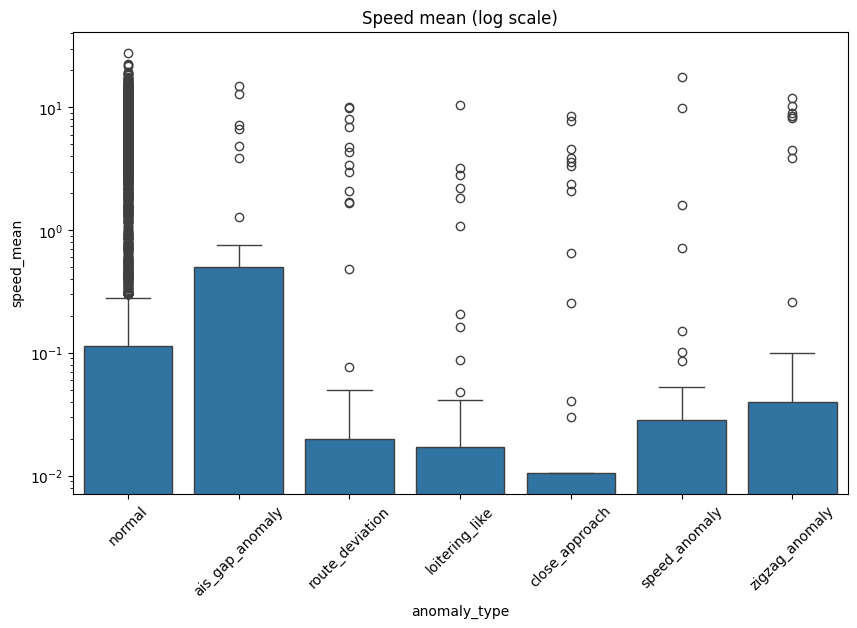

In [ ]:

plt.figure(figsize=(10,6))
sns.boxplot(data=sample_plot, x="anomaly_type", y="speed_mean")
plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Speed mean (log scale)")
plt.show()

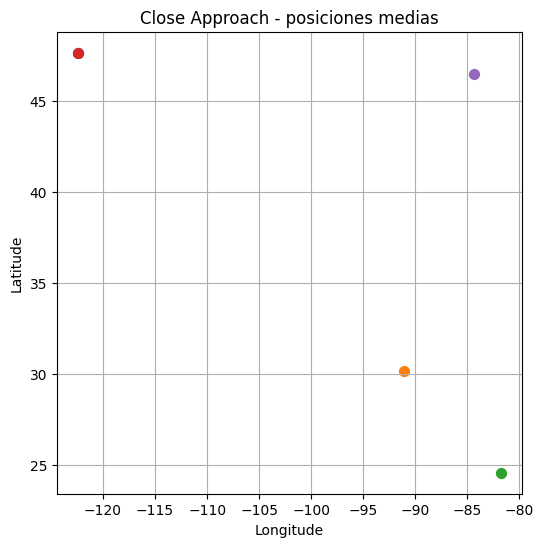

In [ ]:
import matplotlib.pyplot as plt

# coger solo close approach
close_df = test_augmented[test_augmented["anomaly_type"] == "close_approach"]

# coger una muestra de segmentos
sample_close = close_df.sample(n=5, random_state=42)

plt.figure(figsize=(6,6))

for i, row in sample_close.iterrows():
    plt.scatter(row["lon_mean"], row["lat_mean"], s=50)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Close Approach - posiciones medias")
plt.grid()
plt.show()

In [ ]:
import folium

# coger una muestra pequeña
sample_close = close_df.sample(n=50, random_state=42)

# centro del mapa
center = [sample_close["lat_mean"].mean(), sample_close["lon_mean"].mean()]

m = folium.Map(location=center, zoom_start=6)

# añadir puntos
for _, row in sample_close.iterrows():
    folium.CircleMarker(
        location=[row["lat_mean"], row["lon_mean"]],
        radius=4,
        color="red",
        fill=True
    ).add_to(m)

m

ESTO NO SON ENCUENTROS REALES ENTRE BARCOS

La anomalía de tipo close approach no representa interacciones reales entre embarcaciones, sino una aproximación basada en comportamiento individual. Debido a la naturaleza del dataset, que contiene trayectorias independientes por barco, no se dispone de información suficiente para modelar explícitamente encuentros entre múltiples buques. En su lugar, se simulan patrones compatibles con este fenómeno, como baja velocidad, proximidad geográfica y actividad de maniobra.

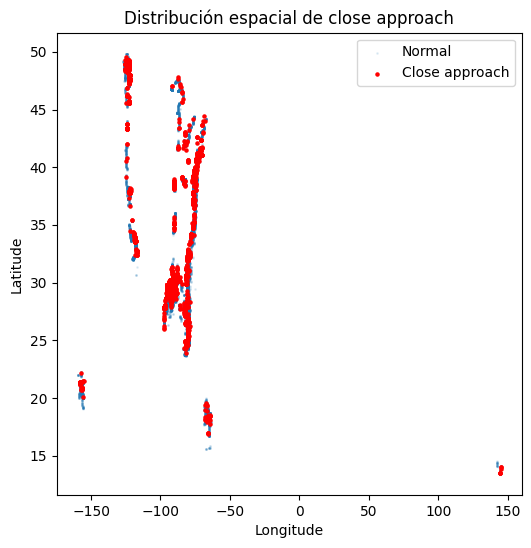

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(
    test_augmented["lon_mean"],
    test_augmented["lat_mean"],
    s=1,
    alpha=0.1,
    label="Normal"
)

close_df = test_augmented[test_augmented["anomaly_type"] == "close_approach"]

plt.scatter(
    close_df["lon_mean"],
    close_df["lat_mean"],
    color="red",
    s=5,
    label="Close approach"
)

plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución espacial de close approach")
plt.show()

Para la visualización de los resultados, se seleccionó una región geográfica con alta densidad de tráfico marítimo, con el objetivo de facilitar la interpretación de los patrones espaciales. Esta selección no afecta al modelo, sino que permite representar de forma más clara la distribución de las anomalías en relación con el tráfico normal.

Se seleccionó una región costera del Golfo de México y Florida debido a su elevada densidad de tráfico marítimo. Esta selección permite visualizar de forma más clara la relación entre el comportamiento normal y las anomalías sintéticas, facilitando la interpretación de los resultados.

En particular, las anomalías de tipo close approach aparecen en zonas donde existe tráfico, lo que refuerza su interpretación como comportamientos compatibles con encuentros entre embarcaciones, aunque no se modelen explícitamente interacciones multibuque.

Puntos en la zona: 58110


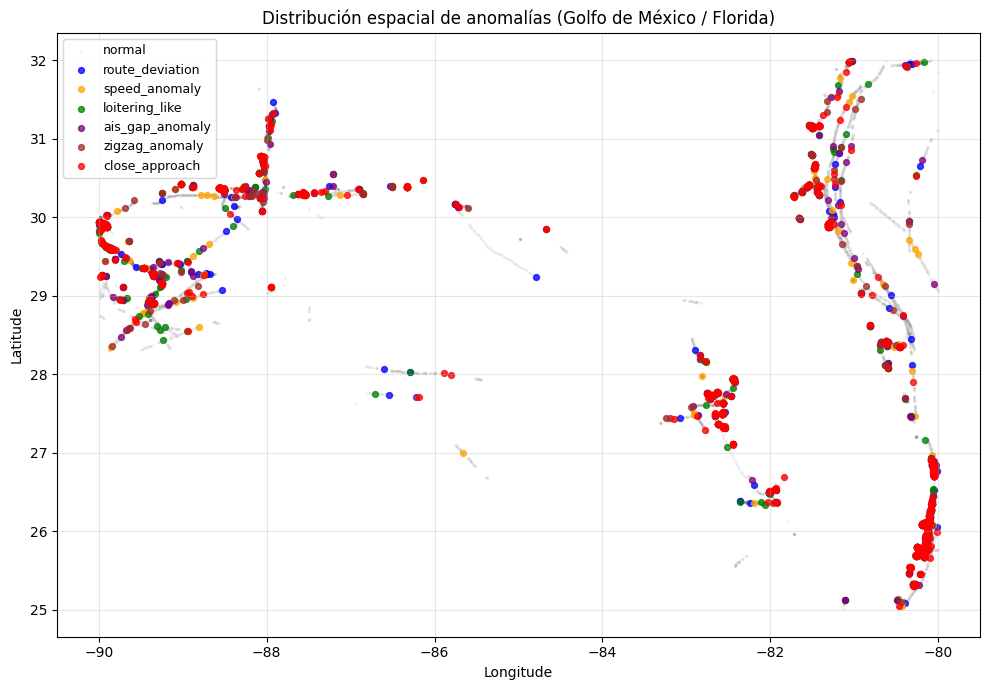

Imagen guardada en: /content/drive/MyDrive/TFG/data_processed/anomaly_map_gulf_florida.png


In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. Definir zona (Golfo de México / Florida)
# -----------------------------
subset = test_augmented[
    (test_augmented["lat_mean"] > 25) &
    (test_augmented["lat_mean"] < 32) &
    (test_augmented["lon_mean"] > -90) &
    (test_augmented["lon_mean"] < -80)
].copy()

print("Puntos en la zona:", len(subset))

# -----------------------------
# 2. Separar normales y anomalías
# -----------------------------
normal_subset = subset[subset["anomaly_type"] == "normal"]

colors = {
    "route_deviation": "blue",
    "speed_anomaly": "orange",
    "loitering_like": "green",
    "ais_gap_anomaly": "purple",
    "zigzag_anomaly": "brown",
    "close_approach": "red"
}

# -----------------------------
# 3. Crear figura
# -----------------------------
plt.figure(figsize=(10, 7))

# fondo (tráfico normal)
plt.scatter(
    normal_subset["lon_mean"],
    normal_subset["lat_mean"],
    s=2,
    alpha=0.08,
    color="gray",
    label="normal"
)

# anomalías
for anomaly, color in colors.items():
    sub = subset[subset["anomaly_type"] == anomaly]

    if len(sub) > 0:
        plt.scatter(
            sub["lon_mean"],
            sub["lat_mean"],
            s=18,
            alpha=0.75,
            color=color,
            label=anomaly
        )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribución espacial de anomalías (Golfo de México / Florida)")
plt.legend(frameon=True, fontsize=9)
plt.grid(alpha=0.3)

# -----------------------------
# 4. Guardar imagen
# -----------------------------
output_path = base_path + "anomaly_map_gulf_florida.png"

plt.tight_layout()
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Imagen guardada en:", output_path)

La frecuencia de las anomalías sintéticas no refleja necesariamente su ocurrencia real en el tráfico marítimo. En particular, el número de casos de close approach es superior al esperado en un entorno real. No obstante, esta decisión se tomó deliberadamente para disponer de un número suficiente de ejemplos que permita evaluar de forma robusta la capacidad del modelo para detectar este tipo de comportamiento.

## Guardado y resumen

In [ ]:
train_clean.to_csv(base_path + "train_clean.csv", index=False)
test_augmented.to_csv(base_path + "test_augmented.csv", index=False)

print("Guardados:")
print("- train_clean.csv")
print("- test_augmented.csv")

Guardados:
- train_clean.csv
- test_augmented.csv


In [ ]:
print("Resumen final")
print("-------------")
print("Train limpio:", train_clean.shape)
print("Test base:", test_base.shape)
print("Test aumentado:", test_augmented.shape)
print()

print("Anomalías sintéticas generadas:", (test_augmented["is_synthetic"] == 1).sum())
print("Proporción sintética: {:.2%}".format((test_augmented["is_synthetic"] == 1).mean()))
print()

print("Distribución final por tipo de anomalía:")
print(test_augmented["anomaly_type"].value_counts())

Resumen final
-------------
Train limpio: (1228043, 37)
Test base: (295078, 37)
Test aumentado: (312778, 39)

Anomalías sintéticas generadas: 17700
Proporción sintética: 5.66%

Distribución final por tipo de anomalía:
anomaly_type
normal             295078
route_deviation      2950
speed_anomaly        2950
ais_gap_anomaly      2950
zigzag_anomaly       2950
loitering_like       2950
close_approach       2950
Name: count, dtype: int64
